# Protein Binding Dataset

In [1]:
import numpy as np
import pandas as pd
# import pickle as pickle
import gudhi as gd  
from sklearn import manifold

Vietoris-Rips Complex: in metric space $\mathbb{X}$, form a simplex for every finite subset of $\mathbb{X}$ that has diameter at most $\alpha$.

Maltose-binding protein has 370 amino acid residues. We are using dynamical distances $D_{ij}=1-|C_{ij}|$, where $C$ is the correlation matrix between residues. 

In [2]:
path_file = "C:/Users/joann/Documents/Classes/Masters/Thesis/Code/corr/"
files_list = [
    '1anf.corr_1.txt', 
    '1ez9.corr_1.txt', 
    '1fqa.corr_2.txt', 
    '1fqb.corr_3.txt', 
    '1fqc.corr_2.txt', 
    '1fqd.corr_3.txt', 
    '1jw4.corr_4.txt', 
    '1jw5.corr_5.txt', 
    '1lls.corr_6.txt', 
    '1mpd.corr_4.txt', 
    '1omp.corr_7.txt', 
    '3hpi.corr_5.txt', 
    '3mbp.corr_6.txt', 
    '4mbp.corr_7.txt'
]
corr_list = [
    pd.read_csv(
        path_file + u, 
        header = None, 
        sep='\s+'
    ) for u in files_list
]

In [3]:
# Finding distances
distances = [1 - np.abs(c) for c in corr_list]
print(len(distances))
D = distances[0]
D.head()

14


,0,1,2,3,4,5,6,7,8,9,...,360,361,362,363,364,365,366,367,368,369
0,0.000000,0.076200,0.171364,0.378207,0.461747,0.493499,0.478665,0.432338,0.568455,0.639504,...,0.694159,0.723059,0.660802,0.614051,0.660601,0.686334,0.640850,0.617944,0.695108,0.748451
1,0.076200,0.000000,0.122763,0.233837,0.350744,0.406213,0.425202,0.381799,0.541636,0.646580,...,0.817461,0.844610,0.781266,0.740222,0.793586,0.808770,0.754748,0.730646,0.804961,0.848953
2,0.171364,0.122763,0.000000,0.084642,0.131528,0.148980,0.162259,0.164105,0.333175,0.480605,...,0.782234,0.813481,0.718610,0.666239,0.742311,0.740322,0.667525,0.653546,0.742430,0.766030
3,0.378207,0.233837,0.084642,0.000000,0.045478,0.132107,0.217299,0.293902,0.494307,0.675635,...,0.913930,0.929677,0.853475,0.813717,0.868041,0.856491,0.797437,0.781044,0.842591,0.858435
4,0.461747,0.350744,0.131528,0.045478,0.000000,0.059280,0.146850,0.297257,0.511751,0.734412,...,0.967195,0.979578,0.889375,0.841519,0.895967,0.874522,0.804538,0.779865,0.841695,0.849836


Making a 1-skeleton: points and edges, but no triangles yet. I think max_edge_length is the alpha parameter.

In [4]:
skeleton_1 = gd.RipsComplex(distance_matrix = D.values, max_edge_length = 0.8)

In [5]:
Rips_simplex_tree = skeleton_1.create_simplex_tree(max_dimension = 2)

print(f"Dimension: {Rips_simplex_tree.dimension()}")
print(f"Number of Vertices: {Rips_simplex_tree.num_vertices()}")
print(f"Number of Simplices: {Rips_simplex_tree.num_simplices()}")

Dimension: 2
Number of Vertices: 370
Number of Simplices: 1626660


## Bar Code Diagram

In [6]:
bar_codes = Rips_simplex_tree.persistence()

c:\Users\joann\anaconda3\envs\gudhi_env\Lib\site-packages\gudhi\persistence_graphical_tools.py:129: UserWarning: usetex mode requires TeX.
  warnings.warn("usetex mode requires TeX.")


<Axes: title={'center': 'Persistence barcode'}>

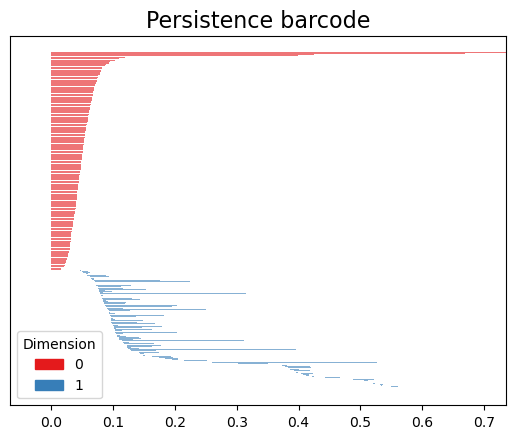

In [7]:
gd.plot_persistence_barcode(bar_codes)

c:\Users\joann\anaconda3\envs\thesis\lib\site-packages\gudhi\persistence_graphical_tools.py:129: UserWarning: usetex mode requires TeX.
  warnings.warn("usetex mode requires TeX.")


<Axes: title={'center': 'Persistence diagram'}, xlabel='Birth', ylabel='Death'>

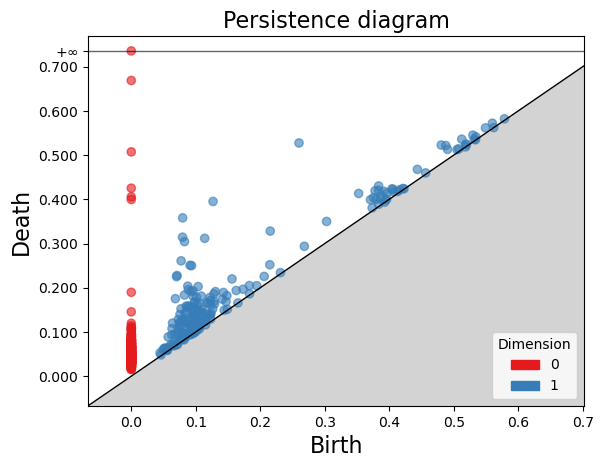

: 

: 

In [ ]:
gd.plot_persistence_diagram(bar_codes)

## Comparing D and D1

In [8]:
D1 = distances[1]

skeleton_2 = gd.RipsComplex(distance_matrix = D1.values, max_edge_length = 0.8)
Rips_simplex_tree2 = skeleton_2.create_simplex_tree(max_dimension = 2)
Bar_codes2 = Rips_simplex_tree2.persistence()


In [ ]:
interval1 = Rips_simplex_tree.persistence_intervals_in_dimension(1)
interval2 = Rips_simplex_tree2.persistence_intervals_in_dimension(1)

gd.bottleneck_distance(interval1, interval2)

0.05052142999999998

: 